1. Implement logistic regression using Python/R to perform classification on
Social_Network_Ads.csv dataset.
2. Compute Confusion matrix to find TP, FP, TN, FN, Accuracy, Error rate, Precision, Recall
on the given dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv("Social_Network_Ads.csv")

In [3]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)

Shape: (400, 5)

Columns:
 Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

Data Types:
 User ID             int64
Gender             object
Age                 int64
EstimatedSalary     int64
Purchased           int64
dtype: object


In [4]:
numeric_cols = ["Age", "EstimatedSalary"]

for col in numeric_cols:
    df.loc[df.sample(frac=0.05, random_state=42).index, col] = np.nan

print("\nMissing Values After Injection:\n", df.isnull().sum())


Missing Values After Injection:
 User ID             0
Gender              0
Age                20
EstimatedSalary    20
Purchased           0
dtype: int64


In [5]:
# Impute missing values for numeric columns
imputer = SimpleImputer(strategy='mean')
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])
print("\nMissing Values After Imputation:\n", df.isnull().sum())


Missing Values After Imputation:
 User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


In [6]:
# Summary statistics
print("\nStatistical Summary:\n", df.describe())


Statistical Summary:
             User ID         Age  EstimatedSalary   Purchased
count  4.000000e+02  400.000000       400.000000  400.000000
mean   1.569154e+07   37.565789     70126.315789    0.357500
std    7.165832e+04   10.180003     33539.410733    0.479864
min    1.556669e+07   18.000000     15000.000000    0.000000
25%    1.562676e+07   30.000000     45000.000000    0.000000
50%    1.569434e+07   37.000000     70126.315789    0.000000
75%    1.575036e+07   45.000000     86250.000000    1.000000
max    1.581524e+07   60.000000    150000.000000    1.000000


In [7]:
print("\nGender Distribution:\n", df["Gender"].value_counts())
print("\nTarget Distribution:\n", df["Purchased"].value_counts())



Gender Distribution:
 Gender
Female    204
Male      196
Name: count, dtype: int64

Target Distribution:
 Purchased
0    257
1    143
Name: count, dtype: int64


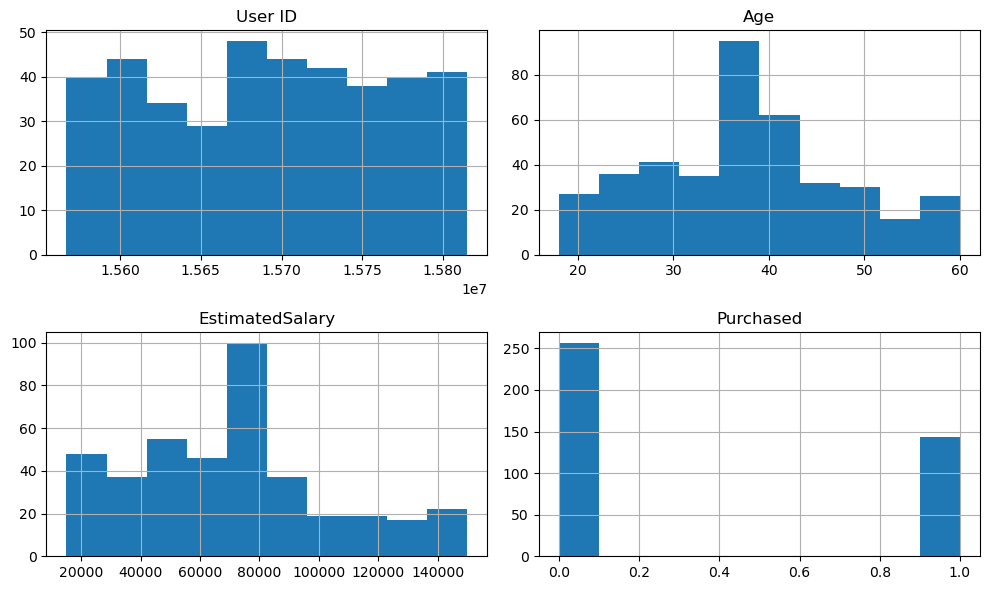

In [8]:
# Histograms
df.hist(figsize=(10, 6))
plt.tight_layout()
plt.show()


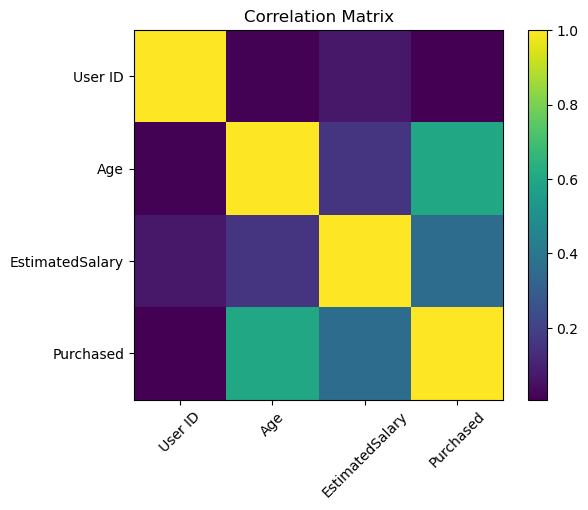

In [9]:
# Correlation matrix
corr = df.corr(numeric_only=True)

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Matrix")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

Number of outliers detected: 4


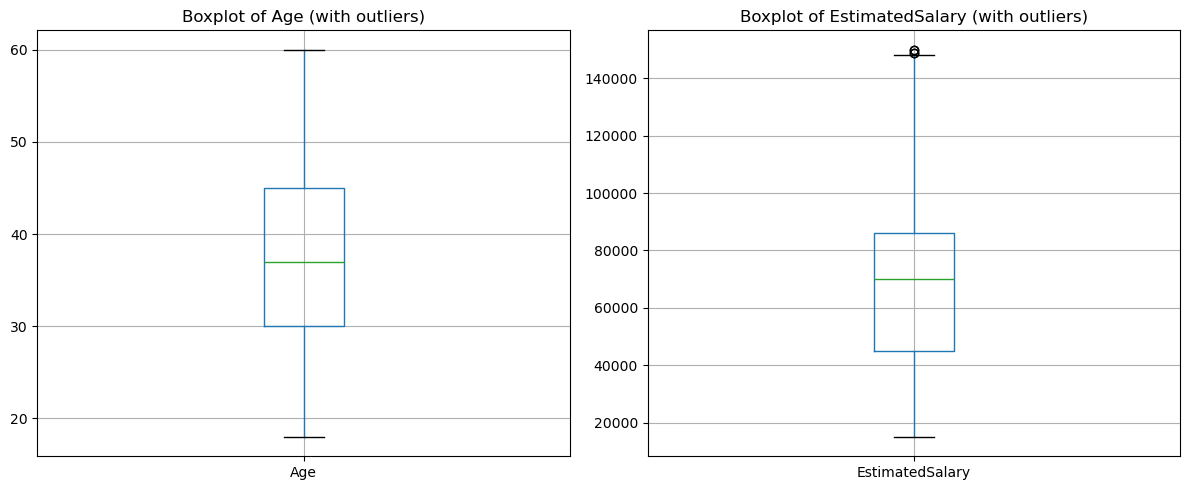

Original dataset shape: (400, 5)
Cleaned dataset shape: (396, 5)
Removed 4 outliers


In [10]:
# Outlier Detection and Removal using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)].index
    return outliers

# Detect outliers in numeric columns
outlier_indices = set()
for col in ['Age', 'EstimatedSalary']:
    outliers = detect_outliers_iqr(df, col)
    outlier_indices.update(outliers)

print(f"Number of outliers detected: {len(outlier_indices)}")

# Visualize outliers with boxplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df.boxplot(column='Age', ax=axes[0])
axes[0].set_title('Boxplot of Age (with outliers)')
df.boxplot(column='EstimatedSalary', ax=axes[1])
axes[1].set_title('Boxplot of EstimatedSalary (with outliers)')
plt.tight_layout()
plt.show()

# Remove outliers
df_clean = df.drop(outlier_indices)
print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape: {df_clean.shape}")
print(f"Removed {len(outlier_indices)} outliers")

# Update dataframe
df = df_clean

In [11]:
# Assign features (X) and target (y)
# Encode categorical features as needed
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])  # 'Male'/'Female' -> 1/0

X = df[['Age', 'EstimatedSalary', 'Gender']].values
y = df['Purchased'].values
print('X shape:', X.shape, 'y shape:', y.shape)

X shape: (396, 3) y shape: (396,)


In [12]:
# Handle missing values (mean imputation)
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

In [14]:
#Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nPreprocessing Completed Successfully!")


Preprocessing Completed Successfully!


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

In [16]:
# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Extract values
TN, FP, FN, TP = cm.ravel()

print("\nTP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
error_rate = 1 - accuracy

print("\nAccuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)


Confusion Matrix:
 [[58 10]
 [ 9 22]]

TP: 22
TN: 58
FP: 10
FN: 9

Accuracy: 0.8080808080808081
Error Rate: 0.19191919191919193
Precision: 0.6875
Recall: 0.7096774193548387


In [17]:
from sklearn.metrics import classification_report

print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.85      0.86        68
           1       0.69      0.71      0.70        31

    accuracy                           0.81        99
   macro avg       0.78      0.78      0.78        99
weighted avg       0.81      0.81      0.81        99



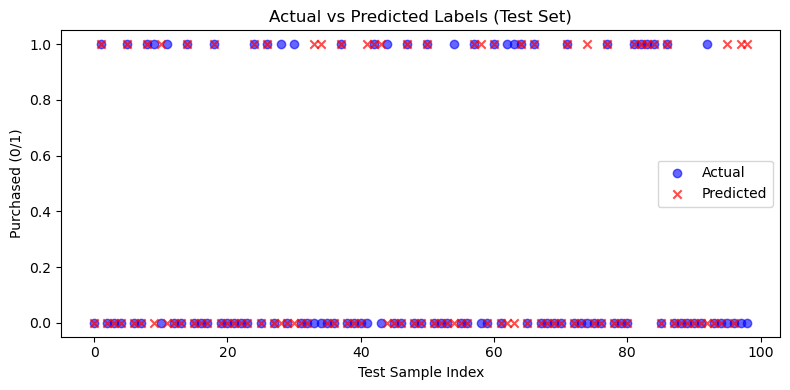

In [18]:
# Plot actual vs predicted for test sample
plt.figure(figsize=(8, 4))
plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual', alpha=0.6)
plt.scatter(range(len(y_pred)), y_pred, color='red', label='Predicted', marker='x', alpha=0.7)
plt.title('Actual vs Predicted Labels (Test Set)')
plt.xlabel('Test Sample Index')
plt.ylabel('Purchased (0/1)')
plt.legend()
plt.tight_layout()
plt.show()